# Diabetic Retinopathy Grading
Train EfficientNet-B5 on the preprocessed dataset with stratified splits and weighted sampling.


In [1]:
import os

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

import timm
from sklearn.model_selection import train_test_split

from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.amp import GradScaler, autocast

import json
import csv
import time
import datetime

from sklearn.metrics import cohen_kappa_score, confusion_matrix
from tqdm.auto import tqdm

import matplotlib.pyplot as plt


/user/HS400/zv00033/miniconda3/envs/diab/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Load Labels & Filter to Existing Images

In [3]:
TRAIN_DIR = Path("dataset/train")
LABELS_CSV = Path("trainLabels.csv")
NUM_CLASSES = 5
IMG_SIZE = 456

df = pd.read_csv(LABELS_CSV)
#Build full file paths and keep only images that are actually there
df["filepath"] = df["image"].apply(lambda x: str(TRAIN_DIR / f"{x}.jpeg"))
df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print(f"Total images found: {len(df)}")
print(f"\nClass distribution:\n{df['level'].value_counts().sort_index()}")

Total images found: 35122

Class distribution:
level
0    25808
1     2442
2     5291
3      873
4      708
Name: count, dtype: int64


## 2. Stratified Train / Val / Test Split (70 / 10 / 20)

In [4]:
#First split keeps 70% for training and the rest for val/test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["level"], random_state=42)

#Second split turns temp into 20% test and 10% val
test_df, val_df = train_test_split(temp_df, test_size=1/3, stratify=temp_df["level"], random_state=42)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  Test: {len(test_df)}  Val: {len(val_df)}")
print(f"\nTrain class distribution:\n{train_df['level'].value_counts().sort_index()}")
print(f"\nTest class distribution:\n{test_df['level'].value_counts().sort_index()}")
print(f"\nVal class distribution:\n{val_df['level'].value_counts().sort_index()}")

Train: 24585  Test: 7024  Val: 3513

Train class distribution:
level
0    18065
1     1709
2     3704
3      611
4      496
Name: count, dtype: int64

Test class distribution:
level
0    5161
1     489
2    1058
3     175
4     141
Name: count, dtype: int64

Val class distribution:
level
0    2582
1     244
2     529
3      87
4      71
Name: count, dtype: int64


## 3. Loss
Treating the problem as regression with MSELoss on a single-output head.
No WeightedRandomSampler: under MSE, oversampling minority classes shifts the
target distribution itself and biases predictions upward — MSE's quadratic
penalty already aligns with QWK's quadratic weights, so we rely on the natural
class distribution instead.


In [5]:
class_counts = train_df["level"].value_counts().sort_index().values

#Treat grades like one regression number from 0 to NUM_CLASSES-1
#Plain MSE is for val/test so val_loss stays comparable across runs
criterion = nn.MSELoss()

#Weighted MSE gives minority classes a bit more attention during training
class_counts_t = torch.tensor(class_counts, dtype=torch.float32, device=device)
N_total = class_counts_t.sum()
K = NUM_CLASSES
class_weights = (N_total / (K * class_counts_t)).sqrt()  #One weight for each DR class

print(f"Class counts (natural distribution kept, no sampler): {dict(enumerate(class_counts))}")
print(f"Class weights (sqrt inverse freq):                    {class_weights.cpu().tolist()}")
print("Loss: Sample-weighted MSE for training, MSE for validation/test")


Class counts (natural distribution kept, no sampler): {0: np.int64(18065), 1: np.int64(1709), 2: np.int64(3704), 3: np.int64(611), 4: np.int64(496)}
Class weights (sqrt inverse freq):                    [0.5217123627662659, 1.696207880973816, 1.1521648168563843, 2.8368051052093506, 3.1485402584075928]
Loss: Sample-weighted MSE for training, MSE for validation/test


## 4. Custom Dataset & Data Augmentations

In [6]:
class DRDatasetFromPaths(Dataset):
    """Dataset that loads images from disk. Labels are returned as float for regression."""

    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGB")
        label = float(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label


### Tranforming the datasets

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]       #ImageNet mean for pretrained EfficientNet
IMAGENET_STD = [0.229, 0.224, 0.225]       #ImageNet std for pretrained EfficientNet

train_transform = T.Compose([
    T.RandomRotation(degrees=360),          #Allow full rotation because retina images can be any angle
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

#Build the datasets
train_dataset = DRDatasetFromPaths(train_df["filepath"].tolist(), train_df["level"].tolist(), transform=train_transform)
test_dataset = DRDatasetFromPaths(test_df["filepath"].tolist(), test_df["level"].tolist(), transform=eval_transform)
val_dataset = DRDatasetFromPaths(val_df["filepath"].tolist(), val_df["level"].tolist(), transform=eval_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")


Train dataset size: 24585
Test dataset size: 7024
Val dataset size: 3513


## 5. DataLoaders

Load the datasets into each variable - train_loader, val_loader, test_loader for training and testing.

In [8]:
BATCH_SIZE = 16                                   #Hit hardware limit
ACCUM_STEPS = 4                                   #Accumulate gradients to get a bigger batch
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * ACCUM_STEPS   #Real batch size after accumulation
NUM_WORKERS = 4

#Keep natural class distribution with MSE, so no sampler here
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Micro batch: {BATCH_SIZE}  |  Accum steps: {ACCUM_STEPS}  |  Effective batch: {EFFECTIVE_BATCH_SIZE}")

Micro batch: 16  |  Accum steps: 4  |  Effective batch: 64


## 6. Load EfficientNet-B5 from timm

In [9]:
#Regression head predicts one continuous DR grade from 0 to NUM_CLASSES-1
model = timm.create_model("efficientnet_b5", pretrained=True, num_classes=1)
model = model.to(device)

print(model.default_cfg["input_size"])      #Model input size
print(f"Classifier: {model.classifier}")    #Classifier layer being used
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")  #Total model parameters

(3, 448, 448)
Classifier: Linear(in_features=2048, out_features=1, bias=True)
Total parameters: 28,342,833


## 7. Training Configuration
Optimizer: AdamW. LR schedule: cosine annealing from `LR` to `1e-6` over all epochs. Mixed-precision scaler for AMP.

In [ ]:
NUM_EPOCHS = 12
# WARMUP_EPOCHS = 1
WARMUP_EPOCHS = 2                           #Warmup epochs from Exp 8
# WARMUP_START_FACTOR = 0.25                  #Warmup starts lower and then reaches LR
WARMUP_START_FACTOR = 0.1                   #Warmup start factor from Exp 8
LR = 2e-4
WEIGHT_DECAY = 1e-4
# ETA_MIN = 1e-5                              #Higher floor because the old run was still improving near the end
ETA_MIN = 1e-6                              #Cosine eta_min from Exp 8
# EARLY_STOP_PATIENCE = 2                     #Stop if QWK does not improve for 2 epochs

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

#Cosine annealing schedule
# scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

#Warm up first, then use cosine for the rest
warmup_scheduler = LinearLR(optimizer, start_factor=WARMUP_START_FACTOR, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=ETA_MIN)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS])

scaler = GradScaler()   #GradScaler helps AMP training stay stable

print(f"Optimizer : AdamW(lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Schedule : LinearLR warmup {WARMUP_EPOCHS} epochs ({WARMUP_START_FACTOR}*LR -> LR) then CosineAnnealingLR over {NUM_EPOCHS - WARMUP_EPOCHS} epochs to eta_min={ETA_MIN}")
print(f"Batch : {BATCH_SIZE}")
print(f"Epochs : {NUM_EPOCHS}")

Optimizer : AdamW(lr=0.0002, weight_decay=0.0001)
Schedule : LinearLR warmup 2 epochs (0.1*LR -> LR) then CosineAnnealingLR over 10 epochs to eta_min=1e-06
Batch : 16
Epochs : 12


## 7.5 Run Logging Setup
Create a timestamped run directory and record every hyperparameter, optimizer/scheduler/loss config, per-epoch metric, final test result, confusion matrix, and timestamps to disk so runs can be compared later.

In [11]:
#Run folder named with timestamp
RUN_TS = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = Path("logs") / f"run_{RUN_TS}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

Path("models").mkdir(parents=True, exist_ok=True)

#Each run gets its own checkpoint name
BEST_CKPT_PATH = str(Path("models") / f"best_efficientnet_b5_{RUN_TS}.pt")

config = {
    "run_ts": RUN_TS,
    "run_dir": str(RUN_DIR),
    "ckpt_path": BEST_CKPT_PATH,
    "seed": 42,

    "model_name": "efficientnet_b5",
    "task": "regression",
    "num_classes": NUM_CLASSES,
    "regression_output_dim": 1,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "accum_steps": ACCUM_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "num_workers": NUM_WORKERS,

    "num_epochs": NUM_EPOCHS,
    "warmup_epochs": WARMUP_EPOCHS,
    "warmup_start_factor": WARMUP_START_FACTOR,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,

    "optimizer": {
        "name": "AdamW",
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    },
    "scheduler": {
        "name": "LinearLR(warmup) -> CosineAnnealingLR",
        "warmup_epochs": WARMUP_EPOCHS,
        "warmup_start_factor": WARMUP_START_FACTOR,
        "cosine_T_max": NUM_EPOCHS - WARMUP_EPOCHS,
        "eta_min": ETA_MIN,
    },
    "criterion": {
        "name": "Sample-weighted MSE (training) / MSELoss (val/test)",
        "class_weights_formula": "(N_total / (K * N_c)) ** 0.5",
        "class_weights": class_weights.cpu().tolist(),
        "prediction_rule": "tuned ordinal thresholds (fit on val) + clip(0, NUM_CLASSES-1)",
    },
    "sampler": {
        "name": "none (natural class distribution)",
        "class_counts": class_counts.tolist(),
    },

    "train_size": len(train_dataset),
    "val_size": len(val_dataset),
    "test_size": len(test_dataset),

    "start_time": datetime.datetime.now().isoformat(timespec="seconds"),
}

with open(RUN_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2, default=str)

#History CSV for each epoch
HISTORY_CSV = RUN_DIR / "history.csv"
with open(HISTORY_CSV, "w", newline="") as f:
    csv.writer(f).writerow(
        ["epoch", "train_loss", "val_loss", "val_acc", "val_qwk", "lr", "epoch_time_s"]
    )

print(f"Logging to {RUN_DIR}")
print(f"Checkpoint -> {BEST_CKPT_PATH}")
print(f"Config written: {RUN_DIR/'config.json'}")

Logging to logs/run_20260502_112943
Checkpoint -> models/best_efficientnet_b5_20260502_112943.pt
Config written: logs/run_20260502_112943/config.json


## 8. Train / Eval Helpers
`train_one_epoch` runs one epoch with AMP, gradient accumulation, and gradient clipping.
`evaluate` runs a no-grad pass and returns loss, accuracy, **quadratic weighted kappa** (metric used in the competition), and the confusion matrix.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device, accum_steps=1, class_weights=None):
    model.train()
    running_loss = 0.0
    n_samples = 0
    num_batches = len(loader)

    optimizer.zero_grad(set_to_none=True)   #Clear old gradients before the first batch

    for step, (input, target) in enumerate(tqdm(loader, desc="train", leave=False)):
        input = input.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True).float()

        with torch.autocast(device_type="cuda"):        #Use AMP so training is faster and lighter on GPU #https://docs.pytorch.org/docs/stable/amp.html
            output = model(input).squeeze(-1)           #Flatten output from [B, 1] to [B]
            if class_weights is not None:
                #Give each sample its class weight before averaging the loss
                sample_w = class_weights[target.long()]
                loss = (sample_w * (output - target) ** 2).mean() / accum_steps
            else:
                loss = criterion(output, target) / accum_steps     #Divide loss so accumulated gradients stay averaged

        scaler.scale(loss).backward()

        is_last_batch = (step + 1) == num_batches
        if (step + 1) % accum_steps == 0 or is_last_batch:  #Update weights after accum batches, and also on the last batch
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        #Put loss back to normal scale before logging it
        running_loss += loss.item() * accum_steps * input.size(0)
        n_samples += input.size(0)

    return running_loss / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device, thresholds=None):
    """Evaluate the model. If `thresholds` (length NUM_CLASSES-1, sorted) is provided,
    map regression outputs -> class via those cutoffs; otherwise fall back to round+clip.
    Always returns the continuous per-sample outputs in the result dict so the caller
    can fit thresholds or run downstream analysis."""
    model.eval()
    running_loss = 0.0
    n_samples = 0
    all_outputs, all_labels = [], []

    for input, target in tqdm(loader, desc="eval", leave=False):
        input = input.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True).float()

        with autocast(device_type="cuda"):
            output = model(input).squeeze(-1)           #Flatten output from [B, 1] to [B]
        loss = criterion(output.float(), target)        #Use float output so eval loss is calculated normally

        all_outputs.append(output.float().cpu().numpy())
        all_labels.append(target.long().cpu().numpy())

        running_loss += loss.item() * input.size(0)
        n_samples += input.size(0)

    outputs = np.concatenate(all_outputs)
    y_true = np.concatenate(all_labels)

    if thresholds is None:
        #AMP can sometimes give NaN outputs in unstable epochs
        #Turn NaN/inf into safe values before rounding
        safe_outputs = np.nan_to_num(outputs, nan=0.0, posinf=NUM_CLASSES - 1, neginf=0.0)
        y_pred = np.clip(np.rint(safe_outputs), 0, NUM_CLASSES - 1).astype(np.int64)
    else:
        y_pred = classify_with_thresholds(outputs, thresholds)

    return {
        "loss": running_loss / n_samples,
        "acc":  (y_pred == y_true).mean(),
        "qwk":  cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "cm":   confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))),
        "y_true": y_true,
        "y_pred": y_pred,
        "outputs": outputs,
    }

## 9. Training Loop
Train, validate, step the LR scheduler, and save the best checkpoint by val QWK.
Stops early if val QWK does not improve for `EARLY_STOP_PATIENCE` epochs.

In [ ]:
best_qwk = -1.0
best_epoch = -1
# epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_qwk": [], "lr": [], "epoch_time_s": []}

train_start_ts = datetime.datetime.now()
train_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  (lr={lr_now:.2e})")

    t0 = time.time()
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device,
        accum_steps=ACCUM_STEPS,
        class_weights=class_weights,
    )
    val = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    epoch_time = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val["loss"])
    history["val_acc"].append(val["acc"])
    history["val_qwk"].append(val["qwk"])
    history["lr"].append(lr_now)
    history["epoch_time_s"].append(epoch_time)

    #Add this epoch row to history.csv
    with open(HISTORY_CSV, "a", newline="") as f:
        csv.writer(f).writerow([
            epoch,
            f"{train_loss:.6f}",
            f"{val['loss']:.6f}",
            f"{val['acc']:.6f}",
            f"{val['qwk']:.6f}",
            f"{lr_now:.8f}",
            f"{epoch_time:.2f}",
        ])

    print(
        f"train_loss={train_loss:.4f}  val_loss={val['loss']:.4f}  "
        f"val_acc={val['acc']:.4f}  val_qwk={val['qwk']:.4f}  "
        f"time={epoch_time:.1f}s"
    )

    if val["qwk"] > best_qwk:
        best_qwk = val["qwk"]
        best_epoch = epoch
        # epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT_PATH)
        print(f"[best] new best val QWK: {best_qwk:.4f} (saved {BEST_CKPT_PATH})")
    else:
        # epochs_no_improve += 1
        # print(f"no improvement ({epochs_no_improve}/{EARLY_STOP_PATIENCE})")
        # if epochs_no_improve >= EARLY_STOP_PATIENCE:
        #     print(f"Early stopping at epoch {epoch}. Best val QWK: {best_qwk:.4f}")
        #     break
        continue

train_end_ts = datetime.datetime.now()
duration_s = time.time() - train_start

summary = {
    "best_qwk": float(best_qwk),
    "best_epoch": int(best_epoch),
    "epochs_completed": len(history["train_loss"]),
    "start_time": train_start_ts.isoformat(timespec="seconds"),
    "end_time": train_end_ts.isoformat(timespec="seconds"),
    "duration_s": round(duration_s, 2),
    "duration_hms": str(datetime.timedelta(seconds=int(duration_s))),
    "ckpt_path": BEST_CKPT_PATH,
}
with open(RUN_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nTraining done. Best val QWK: {best_qwk:.4f} @ epoch {best_epoch}")
print(f"Duration: {summary['duration_hms']}  ({summary['duration_s']}s)")
print(f"Summary written: {RUN_DIR/'summary.json'}")

## 9.5 Tune Ordinal Thresholds on Validation
Default `round()` is equivalent to fixed cutoffs `{0.5, 1.5, 2.5, 3.5}`. With a heavily skewed class distribution, the optimal class-0 / class-1 cutoff is typically below 0.5. Here we coordinate-ascent over the four ordinal thresholds to maximize val QWK directly. The fitted thresholds are then reused for both test and TTA evaluation.

In [ ]:
def classify_with_thresholds(out, thresholds):
    """Map continuous regression outputs to integer class labels using ordered cutoffs.
    `thresholds` must be a sorted iterable of length NUM_CLASSES-1."""
    out = np.asarray(out, dtype=np.float64)         #Make outputs a float array before thresholding
    preds = np.zeros_like(out, dtype=np.int64)      #Start every prediction at class 0
    for t in thresholds:
        preds += (out > t).astype(np.int64)
    return np.clip(preds, 0, NUM_CLASSES - 1)       #Keep predicted classes inside the valid range


def tune_thresholds(val_outputs, val_labels, init=(0.5, 1.5, 2.5, 3.5),
                    grid_radius=0.6, grid_step=0.02, passes=2):
    """Coordinate-ascent search for ordinal cutoffs that maximize val QWK.
    For each threshold, scan a local grid (respecting the strict ordering θ_i<θ_{i+1}),
    pick the value that maximizes QWK, then repeat `passes` times."""
    thresholds = [float(t) for t in init]
    val_labels = np.asarray(val_labels)
    for _ in range(passes):         #Repeat the search to refine the cutoffs
        for i in range(len(thresholds)):
            lo = (thresholds[i - 1] + 1e-3) if i > 0 else -np.inf
            hi = (thresholds[i + 1] - 1e-3) if i < len(thresholds) - 1 else np.inf
            candidates = np.arange(thresholds[i] - grid_radius,
                                   thresholds[i] + grid_radius + 1e-9, grid_step)
            candidates = candidates[(candidates > lo) & (candidates < hi)]
            best_t, best_q = thresholds[i], -1.0
            for t in candidates:
                trial = thresholds[:i] + [float(t)] + thresholds[i + 1:]
                preds = classify_with_thresholds(val_outputs, trial)
                q = cohen_kappa_score(val_labels, preds, weights="quadratic")
                if q > best_q:
                    best_q, best_t = q, float(t)
            thresholds[i] = best_t
    return thresholds, best_q


#Use an older model for threshold tuning without retraining. It will not have History.csv.
#Set this to None to use the current training run instead.
SOURCE_CKPT = "models/best_efficientnet_b5_20260501_082822.pt"

if SOURCE_CKPT is not None:
    BEST_CKPT_PATH = SOURCE_CKPT
    NEW_TS = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    RUN_DIR = Path("logs") / f"run_{NEW_TS}"
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    with open(RUN_DIR / "config.json", "w") as f:
        json.dump({
            "run_ts": NEW_TS,
            "run_dir": str(RUN_DIR),
            "ckpt_path": BEST_CKPT_PATH,
            "kind": "eval-only: threshold tuning applied to existing checkpoint, no retraining",
            "num_classes": NUM_CLASSES,
            "img_size": IMG_SIZE,
            "batch_size": BATCH_SIZE,
            "val_size": len(val_dataset),
            "test_size": len(test_dataset),
            "evaluated_at": datetime.datetime.now().isoformat(timespec="seconds"),
        }, f, indent=2)
    print(f"Logging to new run dir {RUN_DIR}  (checkpoint: {BEST_CKPT_PATH})")

#Load the best checkpoint and collect continuous val outputs
model.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=device))
val_eval = evaluate(model, val_loader, criterion, device)  #No thresholds here, so it uses round()
val_outputs = val_eval["outputs"]
val_labels = val_eval["y_true"]

val_qwk_round = float(val_eval["qwk"])
thresholds, val_qwk_tuned = tune_thresholds(val_outputs, val_labels)

print(f"Val QWK with round() : {val_qwk_round:.4f}")
print(f"Val QWK with tuned thresholds: {val_qwk_tuned:.4f}  (Δ = {val_qwk_tuned - val_qwk_round:+.4f})")
print(f"Tuned thresholds : {[round(t, 4) for t in thresholds]}")

with open(RUN_DIR / "thresholds.json", "w") as f:
    json.dump({
        "thresholds": thresholds,
        "default_thresholds": [0.5, 1.5, 2.5, 3.5],
        "val_qwk_round": val_qwk_round,
        "val_qwk_tuned": val_qwk_tuned,
        "fit": {"grid_radius": 0.6, "grid_step": 0.02, "passes": 2},
    }, f, indent=2)
print(f"Thresholds written: {RUN_DIR/'thresholds.json'}")

Logging to new run dir logs/run_20260502_113025  (checkpoint: models/best_efficientnet_b5_20260501_082822.pt)


Val QWK with round() : 0.8316
Val QWK with tuned thresholds: 0.8447  (Δ = +0.0131)
Tuned thresholds : [0.76, 1.46, 2.32, 3.26]
Thresholds written: logs/run_20260502_113025/thresholds.json


## 10. Final Test Evaluation
Load the best checkpoint (by val QWK) and run it once on the held-out test set. Report QWK, accuracy, and the confusion matrix.

In [ ]:
# BEST_CKPT_PATH = "models/best_efficientnet_b5_20260430_222036.pt"
# RUN_DIR = Path("logs") / "run_20260430_222036"

model.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=device))

eval_start = time.time()
test = evaluate(model, test_loader, criterion, device, thresholds=thresholds)
eval_time = time.time() - eval_start

#Round-rule QWK on the same outputs
test_y_pred_round = np.clip(np.rint(test["outputs"]), 0, NUM_CLASSES - 1).astype(np.int64)
test_qwk_round = float(cohen_kappa_score(test["y_true"], test_y_pred_round, weights="quadratic"))

print(f"Test loss : {test['loss']:.4f}")
print(f"Test acc : {test['acc']:.4f}")
print(f"Test QWK (tuned thresholds): {test['qwk']:.4f}")
print(f"Test QWK (round, ablation) : {test_qwk_round:.4f}  (Δ = {test['qwk'] - test_qwk_round:+.4f})")
print(f"Thresholds used : {[round(t, 4) for t in thresholds]}")

print("\nConfusion matrix (rows=true, cols=pred):")
cm_df = pd.DataFrame(
    test["cm"],
    index=[f"true_{i}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)],
)
print(cm_df)

#Save final test results to the run folder
test_results = {
    "loss": float(test["loss"]),
    "acc": float(test["acc"]),
    "qwk": float(test["qwk"]),
    "qwk_round": test_qwk_round,
    "thresholds": thresholds,
    "ckpt_path": BEST_CKPT_PATH,
    "eval_time_s": round(eval_time, 2),
    "evaluated_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
with open(RUN_DIR / "test_results.json", "w") as f:
    json.dump(test_results, f, indent=2)

np.savetxt(RUN_DIR / "confusion_matrix.csv", test["cm"], fmt="%d", delimiter=",")
np.savez(RUN_DIR / "predictions.npz",
         y_true=test["y_true"], y_pred=test["y_pred"], outputs=test["outputs"])

print(f"\nTest results written: {RUN_DIR/'test_results.json'}")
print(f"Confusion matrix : {RUN_DIR/'confusion_matrix.csv'}")
print(f"Predictions : {RUN_DIR/'predictions.npz'}")

Test loss : 0.2959
Test acc : 0.8078
Test QWK (tuned thresholds): 0.8241
Test QWK (round, ablation) : 0.8137  (Δ = +0.0104)
Thresholds used : [0.76, 1.46, 2.32, 3.26]

Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1  pred_2  pred_3  pred_4
true_0    4849     257      49       4       2
true_1     281     152      53       3       0
true_2     178     191     472     201      16
true_3       6       8      29     119      13
true_4       1       3      18      37      82

Test results written: logs/run_20260502_113025/test_results.json
Confusion matrix : logs/run_20260502_113025/confusion_matrix.csv
Predictions : logs/run_20260502_113025/predictions.npz


## 11. Visualization — Training Curves & Confusion Matrix
Plots metrics from the saved run directory. Defaults to the current run but can use prior `logs/run_YYYYMMDD_HHMMSS/` to compare experiments.

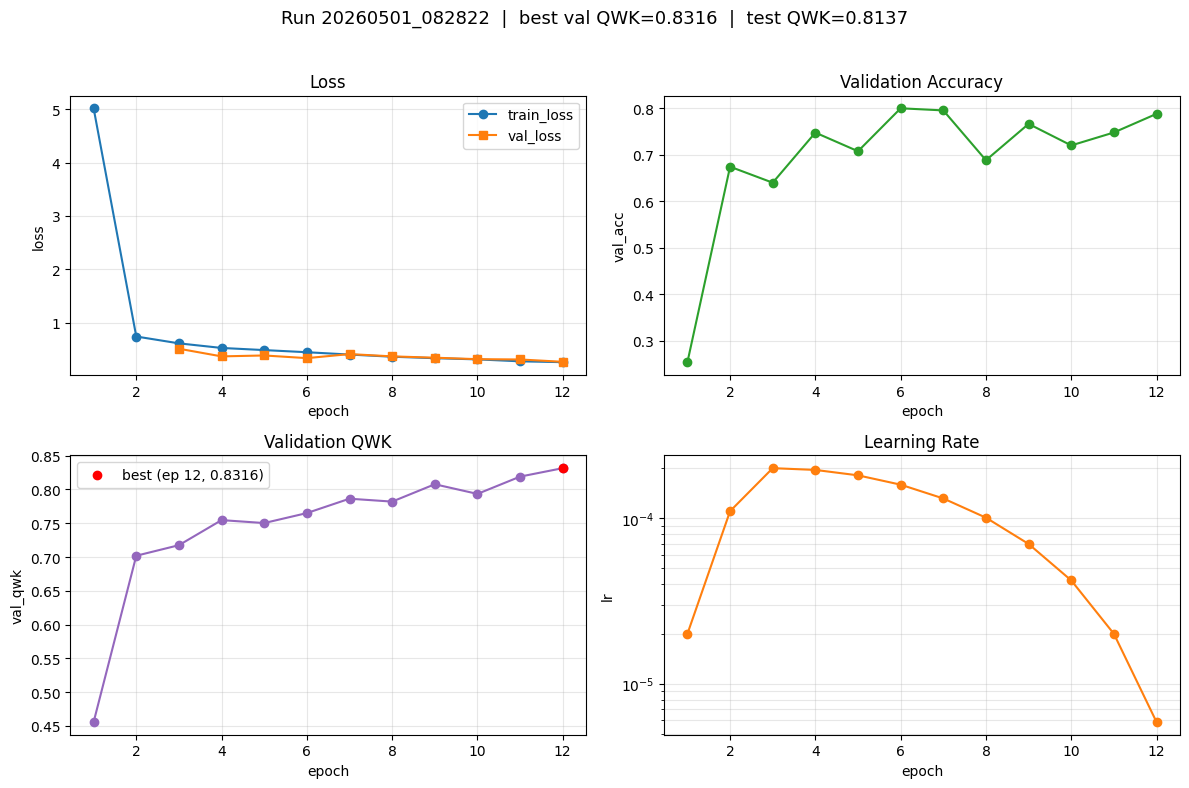

Saved logs/run_20260501_082822/curves.png


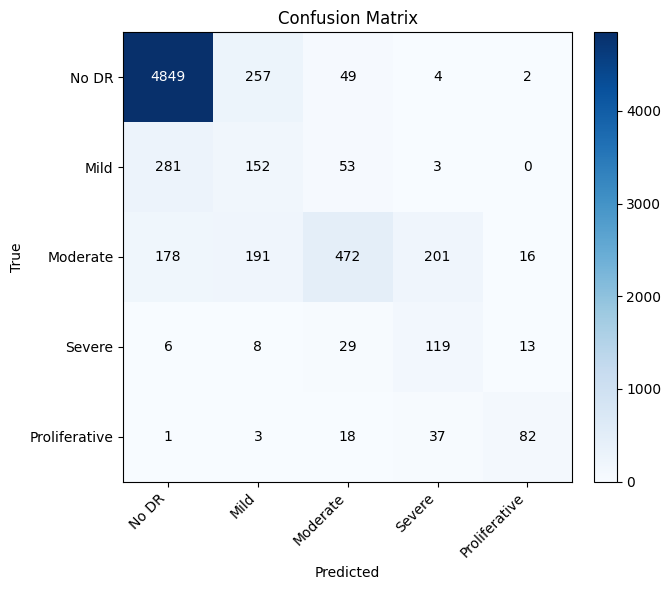

Saved logs/run_20260502_113025/confusion_matrix.png


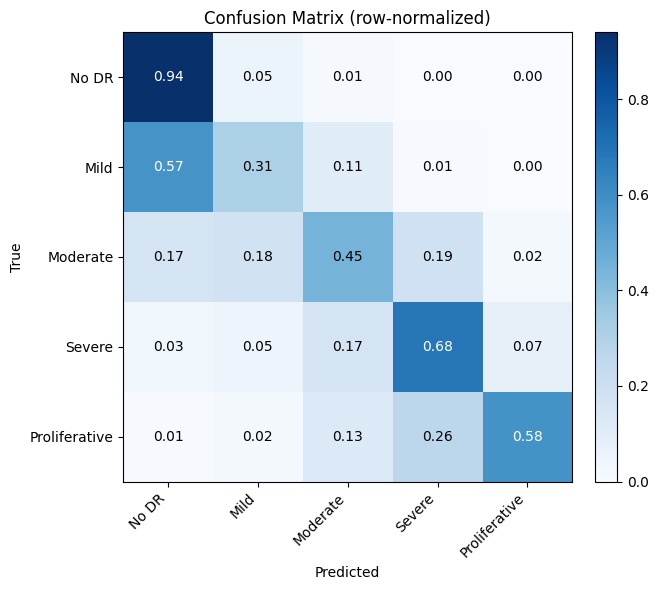

Saved logs/run_20260502_113025/confusion_matrix_norm.png


In [ ]:
def load_run(run_dir):
    run_dir = Path(run_dir)
    hist = pd.read_csv(run_dir / "history.csv")
    with open(run_dir / "config.json") as f:
        cfg = json.load(f)
    summary = None
    if (run_dir / "summary.json").exists():
        with open(run_dir / "summary.json") as f:
            summary = json.load(f)
    test_res = None
    if (run_dir / "test_results.json").exists():
        with open(run_dir / "test_results.json") as f:
            test_res = json.load(f)
    return run_dir, hist, cfg, summary, test_res


def plot_run(run_dir=None):
    """Plot training curves for a run (defaults to the current RUN_DIR)."""
    if run_dir is None:
        run_dir = RUN_DIR
    run_dir, hist, cfg, summary, test_res = load_run(run_dir)

    best_epoch = summary["best_epoch"] if summary else None
    best_qwk = summary["best_qwk"] if summary else None

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    #Loss curves
    ax = axes[0, 0]
    ax.plot(hist["epoch"], hist["train_loss"], marker="o", label="train_loss")
    ax.plot(hist["epoch"], hist["val_loss"], marker="s", label="val_loss")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.set_title("Loss")
    ax.grid(alpha=0.3); ax.legend()

    #Val accuracy
    ax = axes[0, 1]
    ax.plot(hist["epoch"], hist["val_acc"], marker="o", color="tab:green")
    ax.set_xlabel("epoch"); ax.set_ylabel("val_acc")
    ax.set_title("Validation Accuracy")
    ax.grid(alpha=0.3)

    #Val QWK with best epoch marker
    ax = axes[1, 0]
    ax.plot(hist["epoch"], hist["val_qwk"], marker="o", color="tab:purple")
    if best_epoch is not None and best_qwk is not None:
        ax.scatter([best_epoch], [best_qwk], color="red", zorder=5,
                   label=f"best (ep {best_epoch}, {best_qwk:.4f})")
        ax.legend()
    ax.set_xlabel("epoch"); ax.set_ylabel("val_qwk")
    ax.set_title("Validation QWK")
    ax.grid(alpha=0.3)

    #LR schedule
    ax = axes[1, 1]
    ax.plot(hist["epoch"], hist["lr"], marker="o", color="tab:orange")
    ax.set_xlabel("epoch"); ax.set_ylabel("lr")
    ax.set_title("Learning Rate")
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")

    #Add run info in the title
    title_bits = [f"Run {cfg.get('run_ts', run_dir.name)}"]
    if best_qwk is not None:
        title_bits.append(f"best val QWK={best_qwk:.4f}")
    if test_res is not None:
        title_bits.append(f"test QWK={test_res['qwk']:.4f}")
    fig.suptitle("  |  ".join(title_bits), fontsize=13)

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out = run_dir / "curves.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")


def plot_confusion_matrix(run_dir=None, normalize=False):
    """Render the confusion matrix saved in run_dir as a heatmap."""
    if run_dir is None:
        run_dir = RUN_DIR
    run_dir = Path(run_dir)
    cm = np.loadtxt(run_dir / "confusion_matrix.csv", delimiter=",", dtype=int)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        display_cm = np.divide(cm.astype(float), row_sums, where=row_sums != 0, out=None)
        fmt = ".2f"
    else:
        display_cm = cm
        fmt = "d"

    labels = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(display_cm, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    title = "Confusion Matrix (row-normalized)" if normalize else "Confusion Matrix"
    ax.set_title(title)

    #Write values inside each cell
    thresh = display_cm.max() / 2.0 if display_cm.max() > 0 else 0.5
    for i in range(display_cm.shape[0]):
        for j in range(display_cm.shape[1]):
            val = display_cm[i, j]
            text = format(val, fmt)
            color = "white" if val > thresh else "black"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    out = run_dir / ("confusion_matrix_norm.png" if normalize else "confusion_matrix.png")
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")


# plot_run()
# plot_confusion_matrix()
# plot_confusion_matrix(normalize=True)

plot_run("logs/run_20260501_082822")                #Plot history from Exp 8
plot_confusion_matrix("logs/run_20260502_113025")   #Plot confusion matrix from new exp
plot_confusion_matrix("logs/run_20260502_113025", normalize=True)       #Plot normalized confusion matrix from new exp

## 12. Test-Time Augmentation (TTA)
At inference, apply the same random augmentations used during training (rotation,
horizontal flip, vertical flip) to each test image `N_TTA` times. Average the
regression outputs across all augmented passes, then round and clip to
`[0, NUM_CLASSES-1]` to get the final class label. This trades compute for a
typically small but consistent gain on orientation-invariant tasks like fundus grading.


In [ ]:
#TTA config
N_TTA = 16

#Use the same transform as training for TTA
tta_transform = train_transform

@torch.no_grad()
def evaluate_tta(model, dataframe, transform, n_tta, criterion, device,
                 thresholds=None, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    """Run `n_tta` augmented passes over the dataset and average regression outputs.
    If `thresholds` is provided, map averaged outputs -> class via those cutoffs;
    otherwise fall back to round+clip."""
    model.eval()

    filepaths = dataframe["filepath"].tolist()
    labels = dataframe["level"].tolist()
    num_samples = len(labels)

    sum_outputs = np.zeros(num_samples, dtype=np.float64)

    for pass_idx in range(n_tta):           #Run multiple augmented passes and average the outputs
        ds = DRDatasetFromPaths(filepaths, labels, transform=transform)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True)

        pass_outputs = []
        for input, _ in tqdm(loader, desc=f"TTA pass {pass_idx+1}/{n_tta}", leave=False):
            input = input.to(device, non_blocking=True)
            with autocast(device_type="cuda"):
                output = model(input).squeeze(-1)
            pass_outputs.append(output.float().cpu().numpy())
        sum_outputs += np.concatenate(pass_outputs)

    mean_outputs = sum_outputs / n_tta

    y_true = np.array(labels, dtype=np.int64)
    if thresholds is None:
        #Safe NaN handling, same idea as evaluate()
        safe_mean_outputs = np.nan_to_num(mean_outputs, nan=0.0, posinf=NUM_CLASSES - 1, neginf=0.0)
        y_pred = np.clip(np.rint(safe_mean_outputs), 0, NUM_CLASSES - 1).astype(np.int64)
    else:
        y_pred = classify_with_thresholds(mean_outputs, thresholds)

    #MSE after averaging TTA outputs
    loss = float(np.mean((mean_outputs - y_true.astype(np.float64)) ** 2))

    return {
        "loss": loss,
        "acc": float((y_pred == y_true).mean()),
        "qwk": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "cm": confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))),
        "y_true": y_true,
        "y_pred": y_pred,
        "outputs": mean_outputs,
    }


#Load the best checkpoint
model.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=device))

tta_start = time.time()
tta = evaluate_tta(model, test_df, tta_transform, N_TTA, criterion, device, thresholds=thresholds)
tta_time = time.time() - tta_start

#Round-rule QWK on the same TTA outputs
tta_safe_outputs = np.nan_to_num(tta["outputs"], nan=0.0, posinf=NUM_CLASSES - 1, neginf=0.0)
tta_y_pred_round = np.clip(np.rint(tta_safe_outputs), 0, NUM_CLASSES - 1).astype(np.int64)
tta_qwk_round = float(cohen_kappa_score(tta["y_true"], tta_y_pred_round, weights="quadratic"))

print(f"TTA passes : {N_TTA}")
print(f"TTA loss : {tta['loss']:.4f}")
print(f"TTA acc : {tta['acc']:.4f}")
print(f"TTA QWK (tuned thresholds): {tta['qwk']:.4f}")
print(f"TTA QWK (round, ablation) : {tta_qwk_round:.4f}  (Δ = {tta['qwk'] - tta_qwk_round:+.4f})")
print(f"(no-TTA QWK : {test['qwk']:.4f}  |  Δ TTA = {tta['qwk']-test['qwk']:+.4f})")

print("\nTTA confusion matrix (row-normalized, rows=true, cols=pred):")
tta_cm_row_sums = tta["cm"].sum(axis=1, keepdims=True)
tta_cm_norm = np.divide(
    tta["cm"].astype(float), tta_cm_row_sums,
    out=np.zeros_like(tta["cm"], dtype=float), where=tta_cm_row_sums != 0,
)
tta_cm_df = pd.DataFrame(
    tta_cm_norm,
    index=[f"true_{i}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)],
)
print(tta_cm_df.round(4))

#Save TTA results with this run
tta_results = {
    "n_tta": N_TTA,
    "loss": tta["loss"],
    "acc": tta["acc"],
    "qwk": tta["qwk"],
    "qwk_round": tta_qwk_round,
    "thresholds": thresholds,
    "no_tta_qwk": float(test["qwk"]),
    "qwk_delta": float(tta["qwk"] - test["qwk"]),
    "ckpt_path": BEST_CKPT_PATH,
    "eval_time_s": round(tta_time, 2),
    "evaluated_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
with open(RUN_DIR / "tta_results.json", "w") as f:
    json.dump(tta_results, f, indent=2)
np.savetxt(RUN_DIR / "tta_confusion_matrix.csv", tta["cm"], fmt="%d", delimiter=",")
np.savez(RUN_DIR / "tta_predictions.npz",
         y_true=tta["y_true"], y_pred=tta["y_pred"], outputs=tta["outputs"])

print(f"\nTTA results written: {RUN_DIR/'tta_results.json'}")

TTA passes : 16
TTA loss : 0.2892
TTA acc : 0.8067
TTA QWK (tuned thresholds): 0.8273
TTA QWK (round, ablation) : 0.8180  (Δ = +0.0092)
(no-TTA QWK : 0.8241  |  Δ TTA = +0.0032)

TTA confusion matrix (row-normalized, rows=true, cols=pred):
        pred_0  pred_1  pred_2  pred_3  pred_4
true_0  0.9461  0.0450  0.0079  0.0008  0.0002
true_1  0.6196  0.2699  0.1043  0.0061  0.0000
true_2  0.1654  0.1853  0.4272  0.2079  0.0142
true_3  0.0400  0.0457  0.1314  0.6914  0.0914
true_4  0.0000  0.0284  0.1418  0.2766  0.5532

TTA results written: logs/run_20260502_113025/tta_results.json
